In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


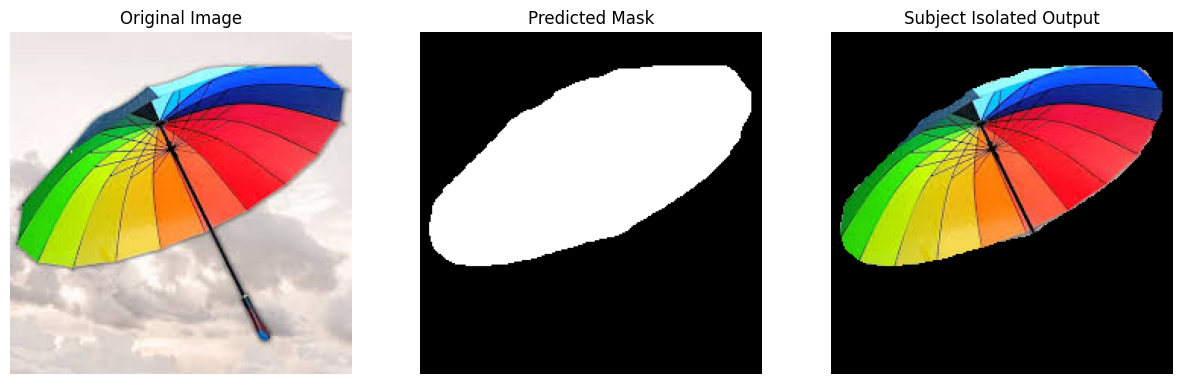

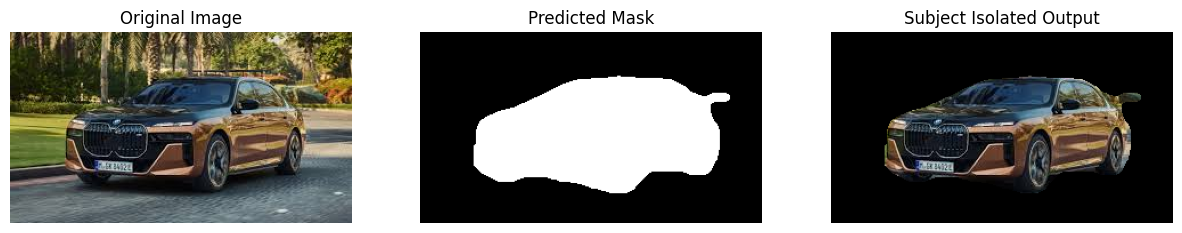

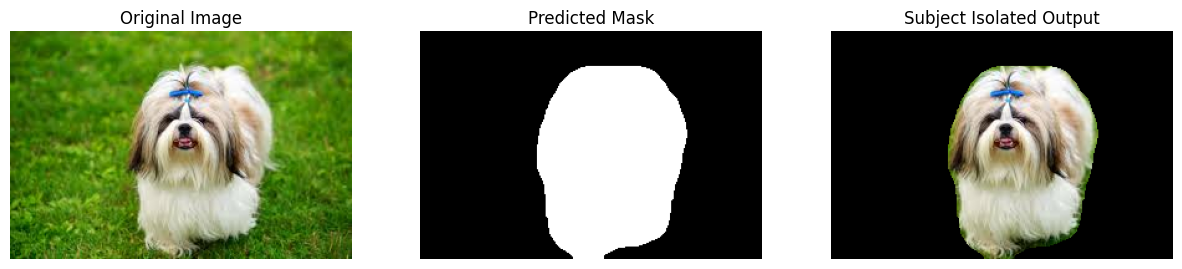

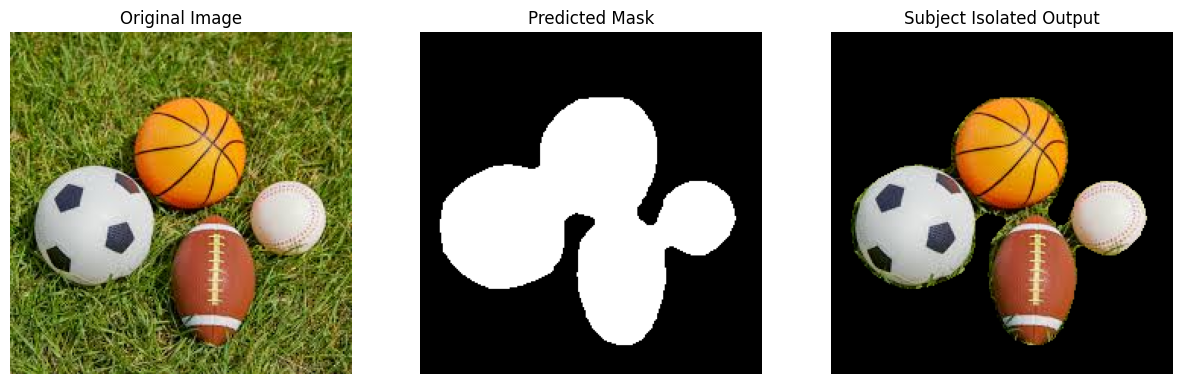

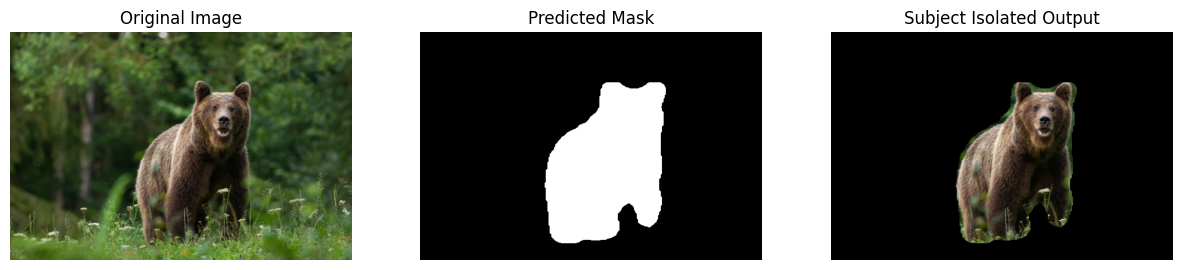

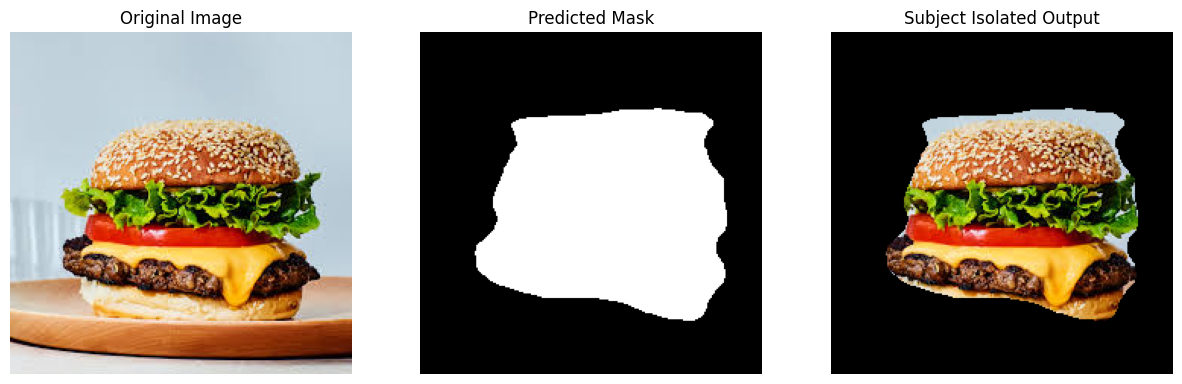

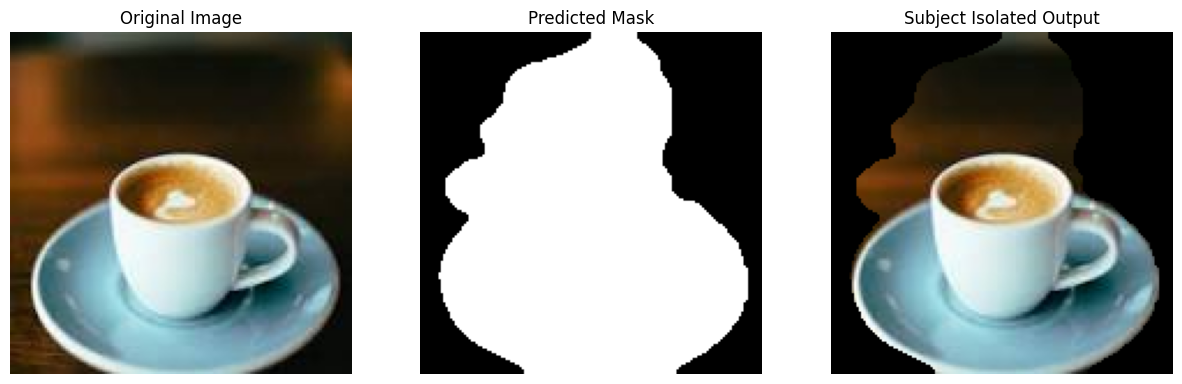

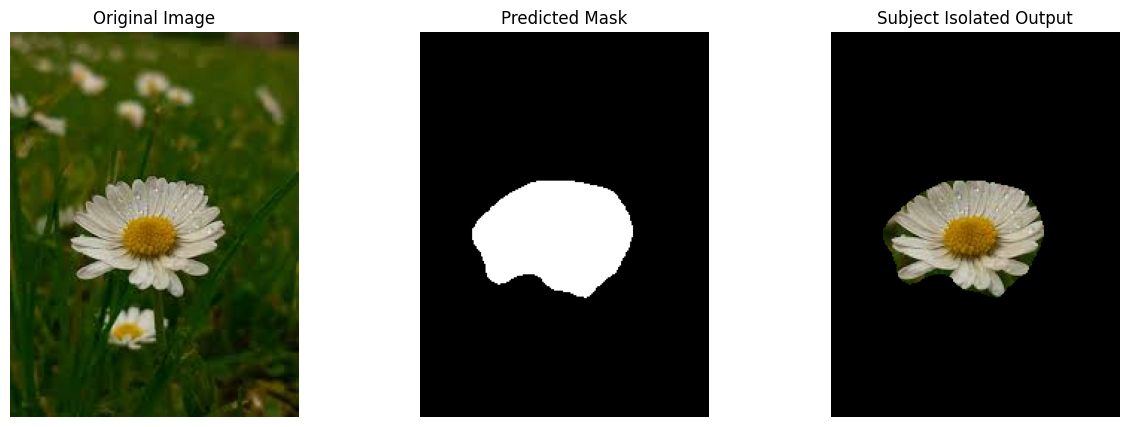

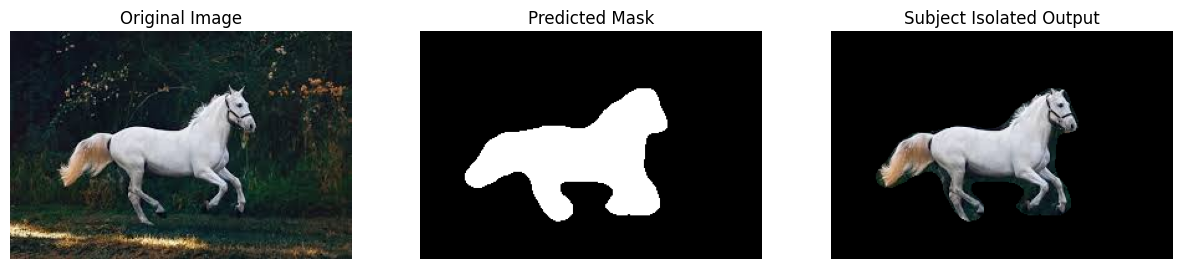

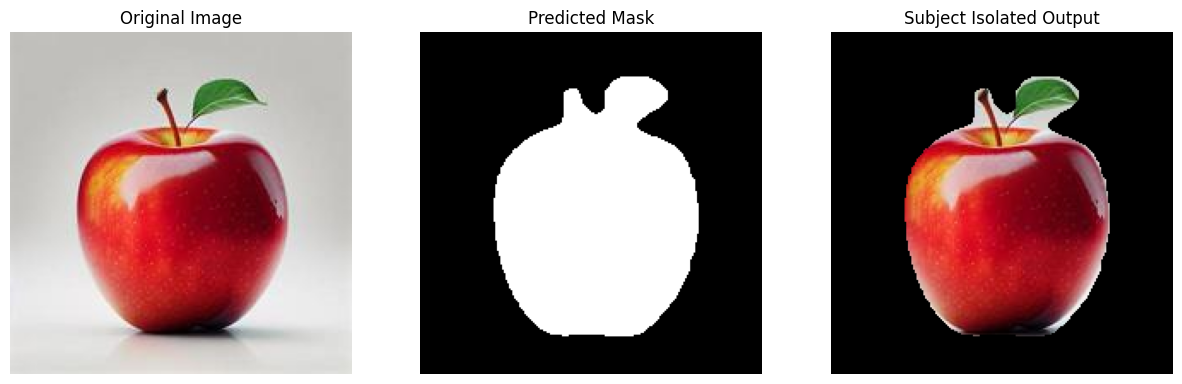

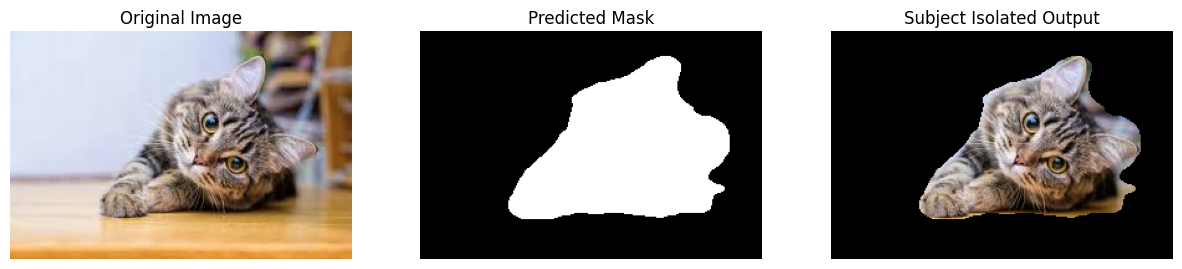

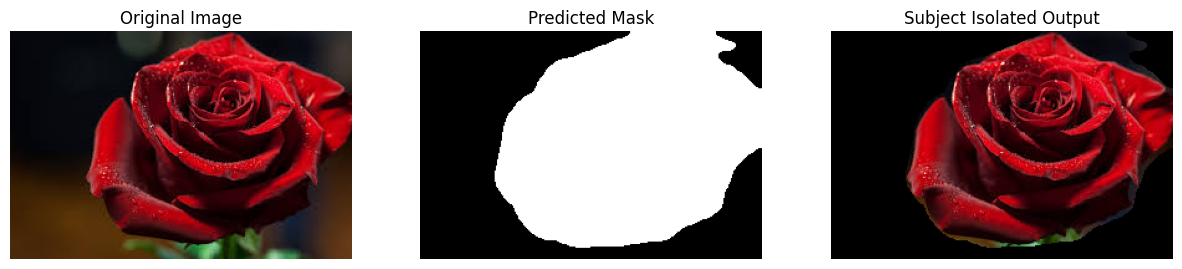

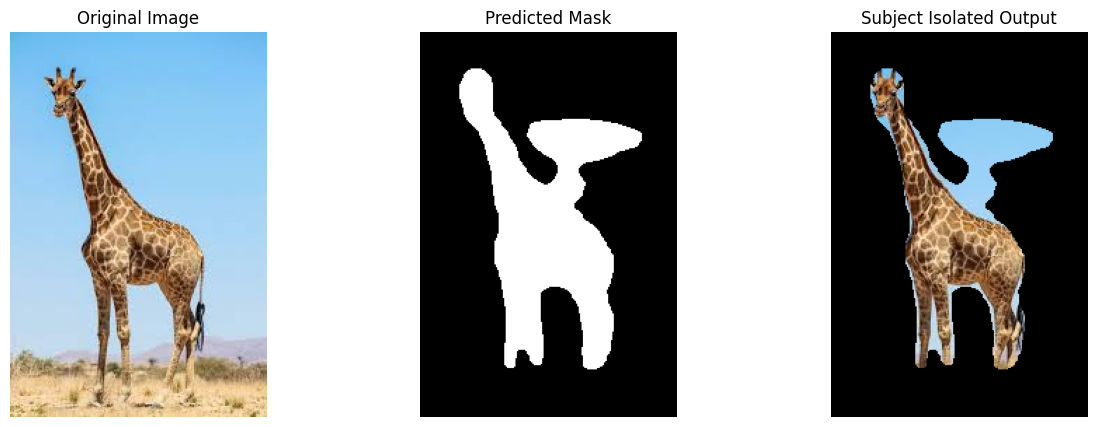

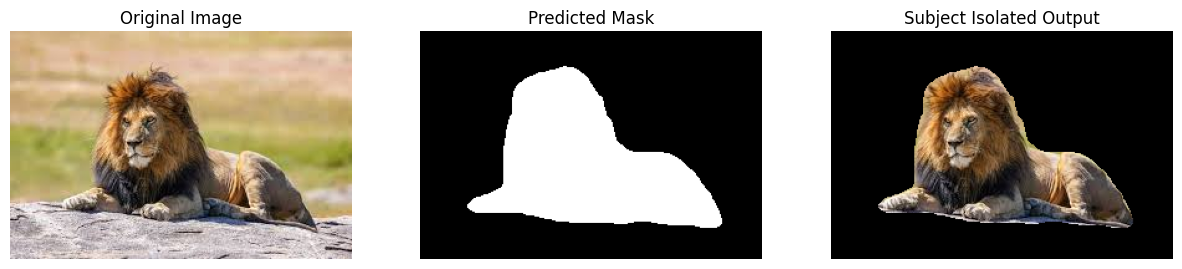

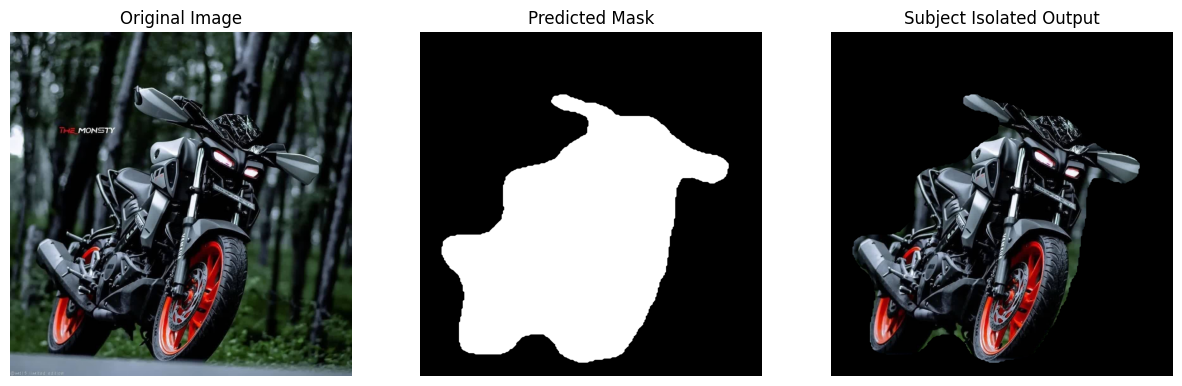

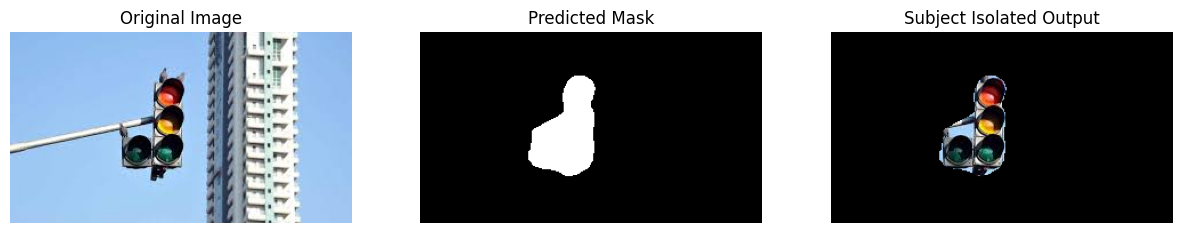

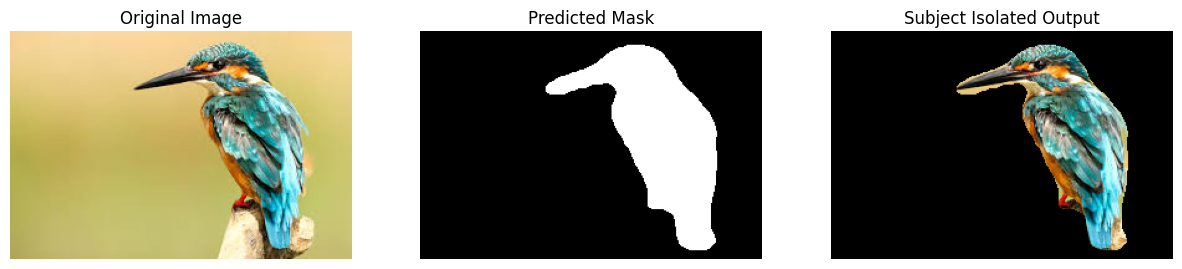

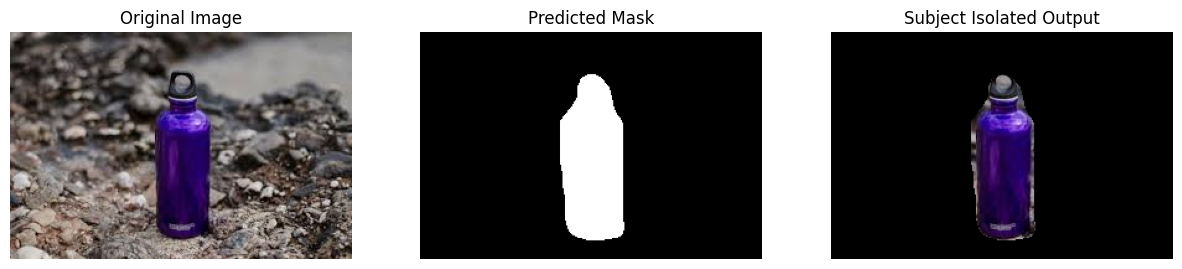

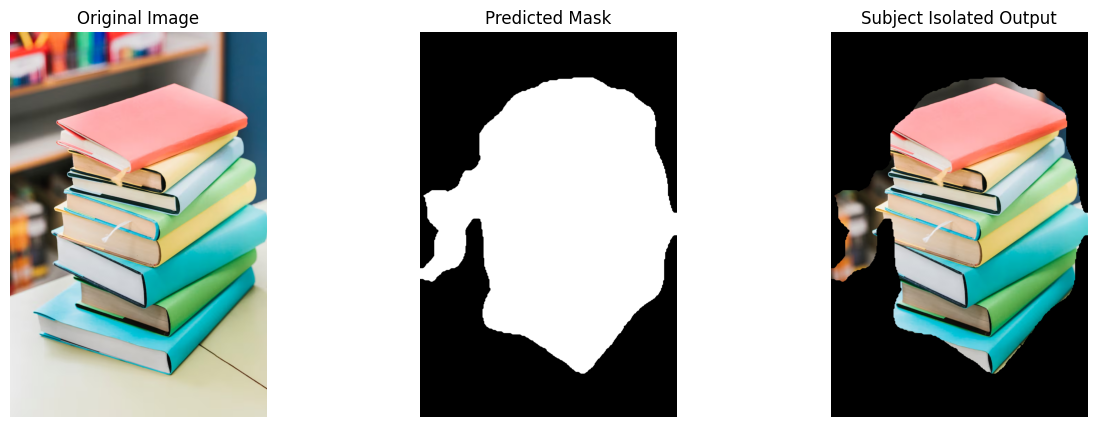

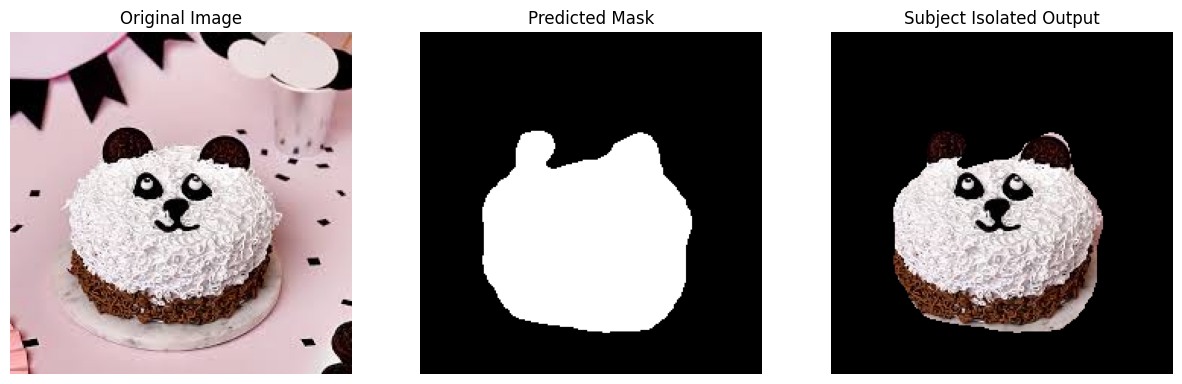

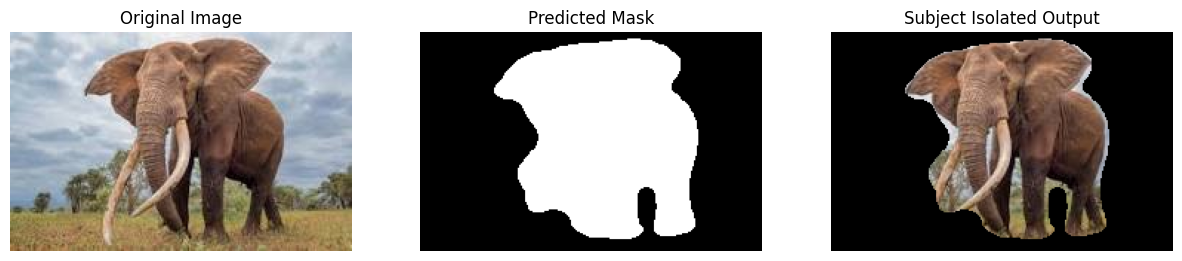

In [1]:
# =========================================
# Week 6: Batch Inference with Original + Mask + Isolated Output
# =========================================

import torch
import torch.nn as nn
import torchvision
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
from PIL import Image
from pathlib import Path

# =========================
# Device & Load Model
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = torchvision.models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = torchvision.models.segmentation.deeplabv3_resnet50(weights=weights)
model.classifier[-1] = nn.Conv2d(256, 1, kernel_size=(1,1))

MODEL_PATH = "/content/drive/MyDrive/VisionExtract/deeplabv3_subject_model.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

# =========================
# Post-processing function
# =========================
def postprocess_mask(mask):
    mask_bin = (mask > 0.5).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask_bin = (labels == largest_label).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel)
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_OPEN, kernel)
    mask_bin = cv2.GaussianBlur(mask_bin.astype(np.float32), (5,5), 0)
    mask_bin = (mask_bin > 0.5).astype(np.uint8)
    return mask_bin

# =========================
# RGB overlay (optional visualization)
# =========================
def apply_rgb_mask(image, mask, color=(0,255,0), alpha=0.5):
    rgb_mask = np.zeros_like(image, dtype=np.uint8)
    rgb_mask[mask==1] = color
    overlay = cv2.addWeighted(image, 1.0, rgb_mask, alpha, 0)
    return overlay

# =========================
# Inference function
# =========================
def inference(image_path, save_dir="output", overlay=True):
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    # Load image
    original_img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(original_img, (256,256))
    img_norm = np.transpose(img_resized / 255.0, (2,0,1)).astype(np.float32)
    img_tensor = torch.tensor(img_norm).unsqueeze(0).to(device)

    # Predict mask
    with torch.no_grad():
        pred = model(img_tensor)['out']
        pred_mask = torch.sigmoid(pred).cpu().squeeze().numpy()
    pred_mask_resized = cv2.resize(pred_mask, (original_img.shape[1], original_img.shape[0]), interpolation=cv2.INTER_NEAREST)
    pred_mask_clean = postprocess_mask(pred_mask_resized)

    # Subject-isolated image
    isolated_subject = original_img * np.expand_dims(pred_mask_clean, axis=2)

    # Save isolated image
    base_name = os.path.basename(image_path)
    save_path = os.path.join(save_dir, f"isolated_{base_name}")
    Image.fromarray(isolated_subject).save(save_path)

    # Optional RGB overlay
    if overlay:
        overlay_img = apply_rgb_mask(original_img, pred_mask_clean, color=(0,255,0), alpha=0.5)
        overlay_path = os.path.join(save_dir, f"overlay_{base_name}")
        Image.fromarray(overlay_img).save(overlay_path)

    return original_img, pred_mask_clean, isolated_subject

# =========================
# Step 4: Process all input images and show outputs
# =========================
input_folder = "/content/drive/MyDrive/VisionExtract/test_images/Input_Images"
output_folder = "/content/drive/MyDrive/VisionExtract/test_images/Output_Images"
Path(output_folder).mkdir(parents=True, exist_ok=True)

all_images = [os.path.join(input_folder, f) for f in os.listdir(input_folder)
              if f.lower().endswith((".png", ".jpg", ".jpeg"))]

for img_path in all_images:
    original, mask, isolated = inference(img_path, save_dir=output_folder)

    # =========================
    # Display all 3 images
    # =========================
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(isolated)
    plt.title("Subject Isolated Output")
    plt.axis("off")

    plt.show()
